In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
using ProgressMeter
using ColorSchemes
using JLD2


In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Lengthscales theory plot v2

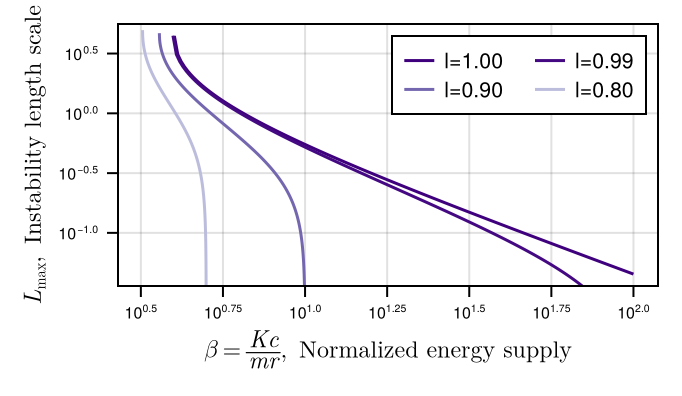

In [12]:
ls = [1., 0.99, 0.9, 0.8]
ps = [1.]

lmin, lmax = extrema(ls)
ldelta = lmax - lmin
pmin, pmax = extrema(ps)
pdelta = pmax - pmin

# cc = cgrad(ColorSchemes.dense[50:end])
cc = cgrad(ColorSchemes.Purples[4:end])
# cc = cgrad(ColorSchemes.Reds[4:end])

fig = Figure(;
    # size=(double_col_width * 1.6, 1.4 * double_col_width / golden_ratio)
    # size=(double_col_width * 0.33, (double_col_width / golden_ratio) * 0.45),
    # padding=(8., 8., 8., 8.),
    # size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.45),
    # figure_padding=(8., 8., 8., 15.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.47),
    figure_padding=(12., 12., 12., 12.),
)
ax = Axis(fig[1,1];
    yscale=log10,
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"L_\text{max},\enspace\text{Instability length scale}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

for p in ps
    for l in ls
        betas = MinimalModelV2.fr2_instab_beta_range(l, p, 1000; betamax=100.)
        km2s = MinimalModelV2.fr2_km2.(betas, l, p, 1.)
        Lms = MinimalModelV2.ksquared_to_L.(km2s)
        
        lines!(ax, betas, Lms;
            label=(@sprintf "l=%.2f" l),
            linestyle=p == 1 ? :solid : :dash,
            color=get(cc, (l - lmin) / ldelta)
        )
    end
end

axislegend(ax;
    labelsize=8fontsize_pt,
    rowgap=2.,
    patchsize=(15, 10),
    nbanks=2,
)

oaoa = (0.5:0.25:2.)
ax.xticks = (10. .^ oaoa, [rich("10", superscript(string(e))) for e in oaoa])

Makie.save("../../figures2/fig2/mm_lengths.pdf", fig)

fig

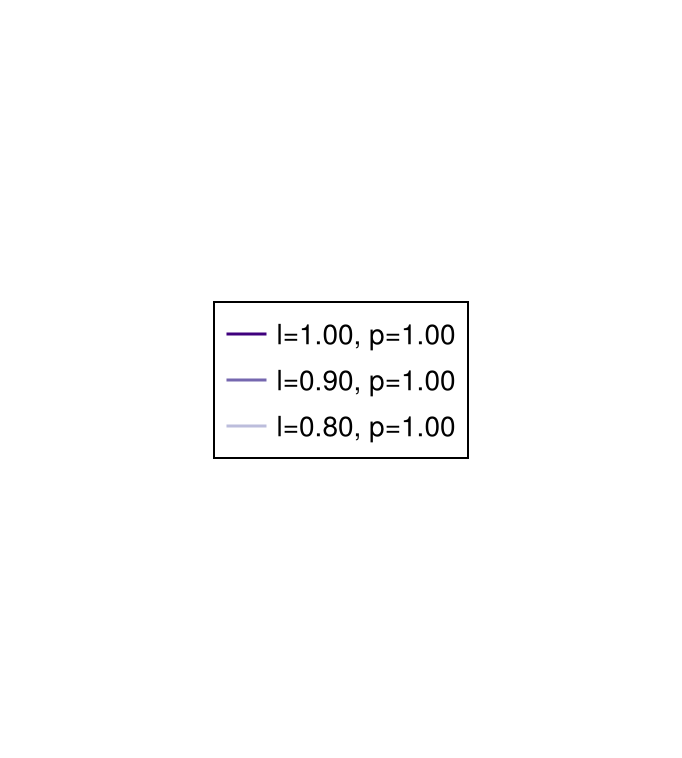

In [21]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.9),
)
Legend(fig[1,1], ax;
    # labelsize=6fontsize_pt,
)
# Makie.save("../../figures2/fig2/mm_lengths_legend.pdf", fig)
fig

In [18]:
b0 = 5
L1 = MinimalModelV2.ksquared_to_L(MinimalModelV2.fr2_km2(10^(b0), 1., 1., 1.))
L2 = MinimalModelV2.ksquared_to_L(MinimalModelV2.fr2_km2(10^(b0+1), 1., 1., 1.))
log10(L2) - log10(L1)

-1.0000068402577265